# Model Building

In [1]:
import pandas as pd
import numpy as np

In [2]:
# loading the dataset 
df=pd.read_csv('placementdata.csv')
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [3]:
# Replacing NaN values
df['salary'] = df['salary'].fillna(0)
# Dropping the 'sl_no' column
df = df.drop(columns=['sl_no'])

print('\n Updated Columns List')
print(df.columns.tolist())


 Updated Columns List
['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'salary']


In [4]:
# Separating features and target variable
X = df.drop(columns=['status', 'salary'])
y = df['status']

print("Features Shape (X)")
print(X.shape)
print("\nTarget Shape (y)")
print(y.shape)

Features Shape (X)
(215, 12)

Target Shape (y)
(215,)


In [5]:
# Converting categorical columns to numerical columns
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

binary_cols = ['gender', 'ssc_b', 'hsc_b', 'workex', 'specialisation']

label_encoders = {}
for col in binary_cols:
    le_col = LabelEncoder()
    X_encoded[col] = le_col.fit_transform(X_encoded[col])
    label_encoders[col] = le_col

X_encoded = pd.get_dummies(X_encoded, columns=['hsc_s', 'degree_t'], drop_first=True, dtype=int)
y_encoded = y.map({'Placed': 1, 'Not Placed': 0})

print("Data Successfully Encoded")
print(X_encoded.head())

Data Successfully Encoded
   gender  ssc_p  ssc_b  hsc_p  hsc_b  degree_p  workex  etest_p  \
0       1  67.00      1  91.00      1     58.00       0     55.0   
1       1  79.33      0  78.33      1     77.48       1     86.5   
2       1  65.00      0  68.00      0     64.00       0     75.0   
3       1  56.00      0  52.00      0     52.00       0     66.0   
4       1  85.80      0  73.60      0     73.30       0     96.8   

   specialisation  mba_p  hsc_s_Commerce  hsc_s_Science  degree_t_Others  \
0               1  58.80               1              0                0   
1               0  66.28               0              1                0   
2               0  57.80               0              0                0   
3               1  59.43               0              1                0   
4               0  55.50               1              0                0   

   degree_t_Sci&Tech  
0                  1  
1                  1  
2                  0  
3               

In [6]:
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets
# We use stratify=y_encoded to keep the 69% / 31% placement split identical in both piles
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print("Train-Test Split Shapes")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

Train-Test Split Shapes
X_train shape: (172, 14)
X_test shape:  (43, 14)
y_train shape: (172,)
y_test shape:  (43,)


In [8]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling
scaler = StandardScaler()

# Identify the continuous numerical columns that need scaling
numerical_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

# Create copies of our dataframes to hold scaled data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit on training data and transform both training and testing sets
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Feature Scaling Complete")
print("Sample scaled training data:")
print(X_train_scaled[numerical_cols].head())

Feature Scaling Complete
Sample scaled training data:
        ssc_p     hsc_p  degree_p   etest_p     mba_p
147  0.260729  0.694120 -0.166768  0.778647  0.000789
161 -1.065759 -1.405431 -1.192126 -1.123471  0.074478
169 -0.664128 -2.212388 -0.678080 -1.359642  0.536711
131  0.712104 -0.857722 -0.576911  0.553721 -0.250425
27  -0.384091  0.055126 -0.030053 -0.345979 -0.767924


### Step 1 : Import libraries

In [10]:
# Importing models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Importing evaluation and tuning tools
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

### Step 2 : Logistic Regression

In [11]:
# 2.1 Setting up Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2.2 Baseline model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2.3 Cross-validated scores across multiple metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
baseline_scores = cross_validate(log_reg, X_train_scaled, y_train, cv=cv, scoring=scoring)

print("Baseline Logistic Regression - 5-Fold CV Results")
for metric in scoring:
    scores = baseline_scores[f'test_{metric}']
    print(f"{metric.capitalize():10s}: {scores.mean():.3f} (+/- {scores.std():.3f})")

Baseline Logistic Regression - 5-Fold CV Results
Accuracy  : 0.854 (+/- 0.049)
Precision : 0.891 (+/- 0.020)
Recall    : 0.898 (+/- 0.069)
F1        : 0.893 (+/- 0.039)
Roc_auc   : 0.939 (+/- 0.040)


### Step 3 : Comparing Multiple Models

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []

for name in models:
    model = models[name]

    score = cross_validate(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring=scoring
    )

    results.append({
        "Model": name,
        "Accuracy": score["test_accuracy"].mean(),
        "Precision": score["test_precision"].mean(),
        "Recall": score["test_recall"].mean(),
        "F1": score["test_f1"].mean(),
        "ROC-AUC": score["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1", ascending=False)
results_df = results_df.reset_index(drop=True)

print("Model Comparison")
print(results_df)

Model Comparison
                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.854454   0.890657  0.898188  0.893271  0.939338
1                  SVM  0.836807   0.857601  0.914855  0.884225  0.921489
2        Random Forest  0.825378   0.856906  0.897826  0.873301  0.923472
3                  KNN  0.813277   0.837913  0.906159  0.869079  0.889516
4    Gradient Boosting  0.813445   0.858924  0.872101  0.860200  0.881815


In [13]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


---
# Hyperparameter Tuning

### Step 1 : Logistic Regression Tuning

In [14]:
log_reg_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

log_reg_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    log_reg_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

log_reg_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", log_reg_grid.best_params_)
print("Best F1 Score:", round(log_reg_grid.best_score_, 4))

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best F1 Score: 0.8981


### Step 2 : SVM Tuning

In [15]:
svm_params = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best F1 Score:", round(svm_grid.best_score_, 4))

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best F1 Score: 0.9022


### Step 3 : Random Forest tuning

In [16]:
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best F1 Score:", round(rf_grid.best_score_, 4))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best F1 Score: 0.8855


### Step 4 : Comparing Tuned Models

In [17]:
best_log_reg = log_reg_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_rf = rf_grid.best_estimator_

tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],
    "Best F1 Score": [
        log_reg_grid.best_score_,
        svm_grid.best_score_,
        rf_grid.best_score_
    ]
})

tuned_results = tuned_results.sort_values("Best F1 Score", ascending=False)
tuned_results = tuned_results.reset_index(drop=True)

print("Tuned Model Comparison")
print(tuned_results)

Tuned Model Comparison
                 Model  Best F1 Score
0                  SVM       0.902245
1  Logistic Regression       0.898097
2        Random Forest       0.885514


In [18]:
print(svm_grid.best_params_)

{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


---
# Final model training and test evaluation

In [19]:
# 4.1 Final model: tuned Logistic Regression
final_model = log_reg_grid.best_estimator_

# 4.2 Fit on the full training set (it's already fit from GridSearchCV, but explicit is clearer)
final_model.fit(X_train_scaled, y_train)

# 4.3 Predict on the held-out test set — touched only once, here
y_pred = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)[:, 1]

In [20]:
# 4.4 Final test set evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

print("Final Model — Logistic Regression (Tuned)")
print(f"Best Params: {log_reg_grid.best_params_}\n")

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Placed', 'Placed']))

Final Model — Logistic Regression (Tuned)
Best Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

Accuracy : 0.8605
Precision: 0.8529
Recall   : 0.9667
F1 Score : 0.9062
ROC-AUC  : 0.9462

Confusion Matrix:
[[ 8  5]
 [ 1 29]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.89      0.62      0.73        13
      Placed       0.85      0.97      0.91        30

    accuracy                           0.86        43
   macro avg       0.87      0.79      0.82        43
weighted avg       0.86      0.86      0.85        43



In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

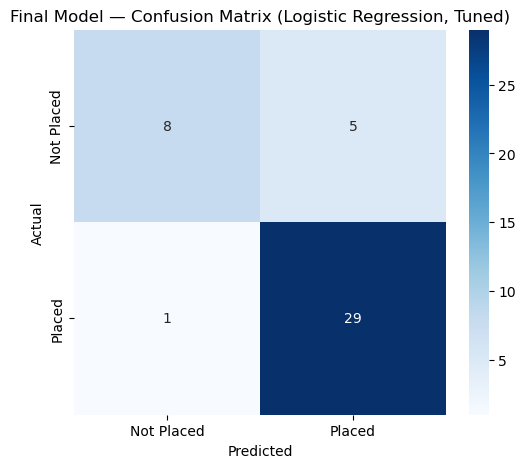

In [23]:
# 4.5 Confusion matrix visualization
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
plt.title('Final Model — Confusion Matrix (Logistic Regression, Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [24]:
# 4.6 Feature coefficients
final_coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': final_model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Final Model Feature Coefficients")
print(final_coef_df)

Final Model Feature Coefficients
              Feature  Coefficient
1               ssc_p     0.913066
5            degree_p     0.633902
3               hsc_p     0.530748
6              workex     0.523363
9               mba_p    -0.443641
0              gender     0.411851
2               ssc_b     0.244716
10     hsc_s_Commerce     0.186072
13  degree_t_Sci&Tech    -0.118736
8      specialisation    -0.080183
4               hsc_b     0.072350
12    degree_t_Others    -0.042833
11      hsc_s_Science     0.038949
7             etest_p    -0.023857


In [25]:
# 5.1 Create a new, hypothetical student record
# Must match your ORIGINAL X columns before encoding (gender, ssc_p, ssc_b, etc.)
new_student = pd.DataFrame({
    'gender': ['M'],
    'ssc_p': [72.5],
    'ssc_b': ['Central'],
    'hsc_p': [68.0],
    'hsc_b': ['Others'],
    'hsc_s': ['Science'],
    'degree_p': [65.0],
    'degree_t': ['Sci&Tech'],
    'workex': ['Yes'],
    'etest_p': [78.0],
    'specialisation': ['Mkt&Fin'],
    'mba_p': [60.0]
})

print("New Student Record:")
print(new_student)

New Student Record:
  gender  ssc_p    ssc_b  hsc_p   hsc_b    hsc_s  degree_p  degree_t workex  \
0      M   72.5  Central   68.0  Others  Science      65.0  Sci&Tech    Yes   

   etest_p specialisation  mba_p  
0     78.0        Mkt&Fin   60.0  


In [26]:
new_student = pd.DataFrame({
    'gender': ['M'], 'ssc_p': [72.5], 'ssc_b': ['Central'],
    'hsc_p': [68.0], 'hsc_b': ['Others'], 'hsc_s': ['Science'],
    'degree_p': [65.0], 'degree_t': ['Sci&Tech'], 'workex': ['Yes'],
    'etest_p': [78.0], 'specialisation': ['Mkt&Fin'], 'mba_p': [60.0]
})

new_student_encoded = new_student.copy()
for col in binary_cols:
    new_student_encoded[col] = label_encoders[col].transform(new_student_encoded[col])

new_student_encoded = pd.get_dummies(new_student_encoded, columns=['hsc_s', 'degree_t'], drop_first=True, dtype=int)
new_student_encoded = new_student_encoded.reindex(columns=X_train.columns, fill_value=0)

new_student_scaled = new_student_encoded.copy()
new_student_scaled[numerical_cols] = scaler.transform(new_student_encoded[numerical_cols])

prediction = final_model.predict(new_student_scaled)
probability = final_model.predict_proba(new_student_scaled)[:, 1]

result = "Placed" if prediction[0] == 1 else "Not Placed"
print(f"Predicted Status: {result}")
print(f"Probability of Placement: {probability[0]:.2%}")

Predicted Status: Placed
Probability of Placement: 87.11%


---

In [28]:
import pickle

with open('final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

with open('numerical_cols.pkl', 'wb') as f:
    pickle.dump(numerical_cols, f)

print("All artifacts saved successfully.")

All artifacts saved successfully.
